In [1]:
import sys


In [2]:
import os
from pathlib import Path
from time import perf_counter

import joblib

project_root = Path.cwd().parent 
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt




In [3]:
from zipfile import ZipFile
with ZipFile('archive (10).zip',mode = 'r') as project_data:
    with project_data.open('hospital_deterioration_hourly_panel.csv',mode = 'r') as deterioration_hourly_panel:
        deterioration_hourly_panel = pd.read_csv(deterioration_hourly_panel)
    with project_data.open('hospital_deterioration_ml_ready.csv',mode = 'r') as deterioration_ml_ready:
        deterioration_ml_ready = pd.read_csv(deterioration_ml_ready)
    with project_data.open('labs_timeseries.csv',mode = 'r') as labs_timeseries:
        labs_timeseries = pd.read_csv(labs_timeseries)
    with project_data.open('patients.csv',mode = 'r') as patients:
        patients = pd.read_csv(patients)
    with project_data.open('vitals_timeseries.csv',mode = 'r') as vitals_timeseries:
        vitals_timeseries = pd.read_csv(vitals_timeseries)

In [4]:
def get_merged_data_w_ids(kwargs, join_cols=['patient_id', 'hour_from_admission'], how='left', strict=True, return_report=False):

    datasets = [(f'df_{i}', df) for i, df in enumerate(kwargs)]

    cleaned = []
    for name, df in datasets:
        usable = [c for c in join_cols if c in df.columns]
        cleaned.append((str(name), df, usable))

    # Start from the dataset with the most available join columns (then most rows).
    cleaned.sort(key=lambda x: (len(x[2]), x[1].shape[0]), reverse=True)
    base_name, merged, base_join_cols = cleaned[0]
    merged = merged.copy()

    for name, df, _ in cleaned[1:]:
        common_cols = [c for c in join_cols if c in merged.columns and c in df.columns]

        # Keep only join keys and columns not yet present in the merged base.
        cols_to_merge = [col for col in df.columns if (col not in merged.columns) or (col in common_cols)]
        dropped_duplicates = [col for col in df.columns if col not in cols_to_merge]
        df_to_merge = df[cols_to_merge].copy()

        left_unique = not merged.duplicated(subset=common_cols).any()
        right_unique = not df_to_merge.duplicated(subset=common_cols).any()
        if left_unique and right_unique:
            relationship = 'one_to_one'
        elif left_unique and not right_unique:
            relationship = 'one_to_many'
        elif not left_unique and right_unique:
            relationship = 'many_to_one'
        else:
            relationship = 'many_to_many'
        
        merged = merged.merge(
            df_to_merge,
            on=common_cols,
            how=how,
            validate=relationship,
            suffixes=('', f'_{name}')
        )

    return merged

In [5]:
datasets = [
            deterioration_hourly_panel,
            labs_timeseries,
            patients,
            vitals_timeseries
            ]

In [6]:
joined_data = get_merged_data_w_ids(kwargs=datasets, join_cols=['patient_id', 'hour_from_admission'], how='left', strict=True, return_report=True)

In [7]:
new_data = joined_data.loc[(joined_data['hour_from_admission'] < joined_data['deterioration_hour']) | (joined_data['deterioration_hour']==-1)]
new_data = new_data[deterioration_ml_ready.columns]
new_data.columns


Index(['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct',
       'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device',
       'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate',
       'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age',
       'gender', 'comorbidity_index', 'admission_type',
       'deterioration_next_12h'],
      dtype='object')

In [8]:
numeric_columns = [i for i in new_data.select_dtypes('number').columns if not i.startswith('deterioration_next_12h')]
categoric_columns = [ i for i in new_data.select_dtypes('object').columns ]
target = 'deterioration_next_12h'
print(numeric_columns)
print('*'*20)
print(categoric_columns)
print('*'*20)
print(target)
print('*'*20)
print('Len cetegoric + numeric + target == len ml_ready columns: ',len(numeric_columns+categoric_columns+[target])==len(deterioration_ml_ready.columns))


['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate', 'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age', 'comorbidity_index']
********************
['oxygen_device', 'gender', 'admission_type']
********************
deterioration_next_12h
********************
Len cetegoric + numeric + target == len ml_ready columns:  True


In [9]:

outlier_thresholds = {}
for col in numeric_columns:
    q1,q3 = np.quantile(deterioration_ml_ready[col],[.25,.75])
    iqr = q3-q1
    lower, upper = q1-(iqr*3), q3+(iqr*3)
    outlier_thresholds[col] = {'lower':lower, 'upper':upper}

print(outlier_thresholds)

{'hour_from_admission': {'lower': np.float64(-68.0), 'upper': np.float64(114.0)}, 'heart_rate': {'lower': np.float64(17.10000000000001), 'upper': np.float64(156.68)}, 'respiratory_rate': {'lower': np.float64(-5.68), 'upper': np.float64(44.58)}, 'spo2_pct': {'lower': np.float64(79.49000000000004), 'upper': np.float64(109.86999999999996)}, 'temperature_c': {'lower': np.float64(35.350000000000016), 'upper': np.float64(38.499999999999986)}, 'systolic_bp': {'lower': np.float64(41.37000000000003), 'upper': np.float64(187.45999999999998)}, 'diastolic_bp': {'lower': np.float64(27.75999999999999), 'upper': np.float64(114.7)}, 'oxygen_flow': {'lower': np.float64(-2.0999999999999996), 'upper': np.float64(2.8)}, 'mobility_score': {'lower': np.float64(-1.0), 'upper': np.float64(6.0)}, 'nurse_alert': {'lower': np.float64(0.0), 'upper': np.float64(0.0)}, 'wbc_count': {'lower': np.float64(-2.4800000000000004), 'upper': np.float64(19.64)}, 'lactate': {'lower': np.float64(-1.0899999999999994), 'upper': 

In [10]:

from sklearn.preprocessing import  (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    RobustScaler,
)

In [11]:
# encode categoric variables 

one_hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
one_hot_encoder.fit(deterioration_ml_ready[categoric_columns])
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
ordinal_encoder.fit(deterioration_ml_ready[categoric_columns])

def encode(encoder, data):
    dataframe = data.copy()
    original_columns = list(encoder.feature_names_in_)
    new_feature_names = encoder.get_feature_names_out(original_columns)

    transformed = encoder.transform(dataframe[original_columns])
    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()
    
    dataframe = dataframe.drop(columns=original_columns)
    dataframe[new_feature_names] = transformed
    return dataframe


In [12]:
#transform/scale numeric variables

sqrt_transformer = FunctionTransformer(lambda x: np.sign(x) * np.sqrt(np.abs(x)), validate=False)
custom_transformer = FunctionTransformer(lambda x: x / (1.0 + np.abs(x)), validate=False)
power_transformer = PowerTransformer()
robust_transformer = RobustScaler()

def numeric_transformer(scaler, data1, data2, data3, data4, columns=numeric_columns):
    dataframe1 = data1.copy()
    dataframe1[columns] = scaler.fit_transform(dataframe1[columns])
    dataframe2 = data2.copy()
    dataframe2[columns] = scaler.transform(dataframe2[columns])
    dataframe3 = data3.copy()
    dataframe3[columns] = scaler.transform(dataframe3[columns])
    dataframe4 = data4.copy()
    dataframe4[columns] = scaler.transform(dataframe4[columns])
    return dataframe1,  dataframe2,  dataframe3,  dataframe4

In [13]:
# balance the data
def balance_binary_classes_equal_false_true(X, y, true_label=1, false_label=0, random_state=43):
    y_arr = np.asarray(y)
    true_idx = np.where(y_arr == true_label)[0]
    false_idx = np.where(y_arr == false_label)[0]

    if len(true_idx) == 0 or len(false_idx) == 0:
        raise ValueError("Both classes must be present to balance data.")

    take_false = min(len(false_idx), len(true_idx))
    rng = np.random.default_rng(random_state)
    sampled_false = rng.choice(false_idx, size=take_false, replace=False)
    kept_idx = np.concatenate([true_idx, sampled_false])
    rng.shuffle(kept_idx)

    X_bal = X.iloc[kept_idx] if hasattr(X, "iloc") else X[kept_idx]
    y_bal = y.iloc[kept_idx] if hasattr(y, "iloc") else y_arr[kept_idx]
    return X_bal, y_bal

In [14]:
from sklearn.model_selection import train_test_split

def analyze_model(pre_deterioration_data, 
                  ml_ready_data,
                  transformer,
                  encoder,
                  clip_outliers: bool = False,
                  outlier_thresholds: dict = outlier_thresholds,
                  target_col: str = target
                  ):
    pre_deterioration = pre_deterioration_data.copy()
    ml_ready = ml_ready_data.copy()

    y = pre_deterioration[target_col].astype(int)
    X = pre_deterioration.drop(columns=target_col)

    X, y = balance_binary_classes_equal_false_true( X, y, random_state=43 )

    # Match parameter-derivation scope: tune-train + validation split from balanced train.
    Xtrain, Xtest, ytrain, ytest = train_test_split(
                                                    X, y, 
                                                    test_size=0.25, 
                                                    random_state=43, stratify=y
                                                )
    Xtrain, Xtest, pre_deterioration, ml_ready  = numeric_transformer(
        transformer, Xtrain, Xtest, pre_deterioration, ml_ready
    )

    Xtrain, Xtest, pre_deterioration, ml_ready = (
                                                    encode(encoder, Xtrain),
                                                    encode(encoder, Xtest),
                                                    encode(encoder, pre_deterioration),
                                                    encode(encoder, ml_ready),
                                                )

    y_pre_det, y_ml = pre_deterioration[target_col], ml_ready[target_col]
    X_pre_det, X_ml = pre_deterioration.drop(columns=target_col), ml_ready.drop(columns=target_col)

    return Xtrain, Xtest, X_pre_det, X_ml, ytrain, ytest, y_pre_det, y_ml, transformer

In [15]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier



### Hyperparameters selected based on validation data, before hold-out 'test' data was seen.  


In [ ]:
def get_params(combined_params:dict):
    booster, base = {}, {}
    for k, v in combined_params.items():
        if '__' in k:
            if k.startswith('estimator__'):
                base[k.replace('estimator__', '', 1)] = v
            else:
                base[k.replace('__', '_', 1)] = v
        else:
            booster[k] = v
    return booster, base

random_forest_params = {'random_state':43,'class_weight': None, 'max_depth': 18, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 
                        'n_estimators': 240}
rand_forest = RandomForestClassifier(**random_forest_params)

xgboost_params       = {'random_state':43, 'max_depth': 6, 'n_estimators': 240, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.9}
xgboost = XGBClassifier(**xgboost_params)

boosted_logistic     = {'random_state':43, 'random__state':43, 'estimator__C': 0.3, 'estimator__max_iter': 800, 'learning_rate': 0.5, 'n_estimators': 70}
log_boost, log_base = get_params(boosted_logistic)
log_boost = AdaBoostClassifier(estimator = LogisticRegression(**log_base),**log_boost)

boosted_mlp          = {'random_state':43, 'estimator__random_state':43, 'estimator__activation': 'tanh', 
                        'estimator__alpha': np.float64(1.814683977744406e-05), 
                        'estimator__hidden_layer_sizes': (12, 6), 
                        'estimator__learning_rate_init': np.float64(0.0018072009122556939), 'estimator__max_iter': 600, 
                        'learning_rate': np.float64(0.14237961777162708), 
                        'n_estimators': 48}
_mlp_boost, mlp_base = get_params(boosted_mlp)
mlp_boost = AdaBoostClassifier(estimator = MLPClassifier(**mlp_base), **_mlp_boost)

boosted_perceptron   = {'random_state':43, 'random__state':43, 'estimator__alpha': np.float64(4.128826827265449e-05), 'estimator__eta0': np.float64(0.008527241847978064), 
                        'estimator__max_iter': 1904, 
                        'estimator__penalty': None, 'learning_rate': np.float64(0.2068898719796122), 'n_estimators': 56}
per_boost, per_base = get_params(boosted_perceptron)
perc_boost = AdaBoostClassifier(estimator = Perceptron(**per_base), **per_boost)

boosted_svc = {'estimator__C': 1.0, 'estimator__kernel': 'rbf', 'estimator__gamma': 'scale', 'learning_rate': 0.2, 'n_estimators': 20}
_svc_boost, svc_base = get_params(boosted_svc)
svc_boost = AdaBoostClassifier(estimator = SVC(probability=True, **svc_base), **_svc_boost)


models = {'XGBoost': {'model':xgboost, 'encoder':ordinal_encoder,'transformer':custom_transformer, 'clip_outliers':False},
          'Randome Forest':{'model':rand_forest, 'encoder':ordinal_encoder,'transformer':sqrt_transformer, 'clip_outliers':False},
          'Boosted Logistic Regression': {'model':log_boost, 'encoder':one_hot_encoder,'transformer':robust_transformer, 'clip_outliers':False},
          'Boosted MLP': {'model':mlp_boost, 'encoder':ordinal_encoder,'transformer':power_transformer, 'clip_outliers':False},
          'Boosted Perceptron': {'model':perc_boost, 'encoder':one_hot_encoder,'transformer':sqrt_transformer, 'clip_outliers':True},          
          #'Boosted SVC': {'model':svc_boost, 'encoder':one_hot_encoder,'transformer':power_transformer, 'clip_outliers':True},
}
          
          
          

In [17]:
from sklearn.metrics import (
        confusion_matrix,
        recall_score,
        precision_score,
        f1_score,
        roc_auc_score,
        roc_curve,
        precision_recall_curve,
        average_precision_score,
    )

def make_plots(model,
               X_vals: list,
               y_values: list,
               data_lables: list):

    if not (len(X_vals) == len(y_values) == len(data_lables)):
        raise ValueError("X_vals, y_values, and data_lables must have equal lengths.")

    rows = []
    cached = []

    for X_i, y_i, label in zip(X_vals, y_values, data_lables):
        y_true = np.asarray(y_i)
        y_pred = model.predict(X_i)

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_i)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_i)
        else:
            y_score = y_pred.astype(float)

        if len(np.unique(y_true)) > 1:
            roc_auc = float(roc_auc_score(y_true, y_score))
        else:
            roc_auc = np.nan

        row = {
            "dataset_label": label,
            "n_rows": int(len(y_true)),
            "recall": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
            "precision": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
            "roc_auc": roc_auc,
        }
        rows.append(row)
        cached.append((label, y_true, y_pred, y_score))

    results_df = pd.DataFrame(rows)
    try:
        display(results_df)
    except NameError:
        print(results_df)

    n = len(cached)
    fig, axes = plt.subplots(n, 3, figsize=(18, 5 * n))
    if n == 1:
        axes = np.array([axes])

    for i, (label, y_true, y_pred, y_score) in enumerate(cached):
        cm_labels = sorted(set(y_true) | set(y_pred))
        cm = confusion_matrix(y_true, y_pred, labels=cm_labels)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=cm_labels,
            yticklabels=cm_labels,
            ax=axes[i, 0],
            cbar=False,
        )
        axes[i, 0].set_title(f"{label} | Confusion Matrix")
        axes[i, 0].set_xlabel("Predicted")
        axes[i, 0].set_ylabel("Actual")

        if len(np.unique(y_true)) > 1:
            fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
            roc_auc = roc_auc_score(y_true, y_score)
            axes[i, 1].plot(fpr, tpr, label=f"AUC={roc_auc:.4f}", linewidth=2)
            axes[i, 1].plot([0, 1], [0, 1], "k--", linewidth=1)

            prec, rec, _ = precision_recall_curve(y_true, y_score, pos_label=1)
            ap = average_precision_score(y_true, y_score, pos_label=1)
            axes[i, 2].plot(rec, prec, label=f"AP={ap:.4f}", linewidth=2)
        else:
            axes[i, 1].text(0.5, 0.5, "ROC unavailable\n(single class)", ha="center", va="center")
            axes[i, 2].text(0.5, 0.5, "PR unavailable\n(single class)", ha="center", va="center")

        axes[i, 1].set_title(f"{label} | ROC-AUC")
        axes[i, 1].set_xlabel("False Positive Rate")
        axes[i, 1].set_ylabel("True Positive Rate")
        axes[i, 1].legend(loc="lower right")
        axes[i, 1].grid(alpha=0.25)

        axes[i, 2].set_title(f"{label} | PR-AUC")
        axes[i, 2].set_xlabel("Recall")
        axes[i, 2].set_ylabel("Precision")
        axes[i, 2].legend(loc="lower left")
        axes[i, 2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()
    return results_df

In [18]:
def analyze_one_model(model,
                    transformer,
                    encoder,
                    clip_outliers: bool = False,                    
                    pre_deterioration_data=None, 
                    ml_ready_data=None,
                    outlier_thresholds: dict = outlier_thresholds,
                    target_col: str = target,
                    plot_labels: list = ['Tune-Train Data',  'Holdout Test Data', 'Complete Pre-Deterioration Data', 'Pre & Post Deterioration Data']):

    Xtrain, Xtest, X_pre_det, X_ml, ytrain, ytest, y_pre_det, y_ml, fitted_transformer = analyze_model(
                                                                                pre_deterioration_data,
                                                                                ml_ready_data,
                                                                                transformer,
                                                                                encoder,
                                                                                clip_outliers=clip_outliers,
                                                                                outlier_thresholds=outlier_thresholds,
                                                                                target_col=target_col,
                                                                            )


    # Train once on the exact parameter-derivation scope: tune-train.
    model.fit(Xtrain, ytrain)

    make_plots(
        model,
        X_vals=[Xtrain, Xtest, X_pre_det, X_ml],
        y_values=[ytrain, ytest, y_pre_det, y_ml],
        data_lables=plot_labels,
    )

    return model,  fitted_transformer
    
    

  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =  
 XGBoost 
 = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 


,dataset_label,n_rows,recall,precision,f1,roc_auc
0,Tune-Train Data,33883,0.940857,0.957415,0.949064,0.990256
1,Holdout Test Data,11295,0.882770,0.898522,0.890576,0.963211
2,Complete Pre-Deterioration Data,382548,0.926336,0.391869,0.550752,0.975638
3,Pre & Post Deterioration Data,417866,0.926336,0.236459,0.376749,0.915444


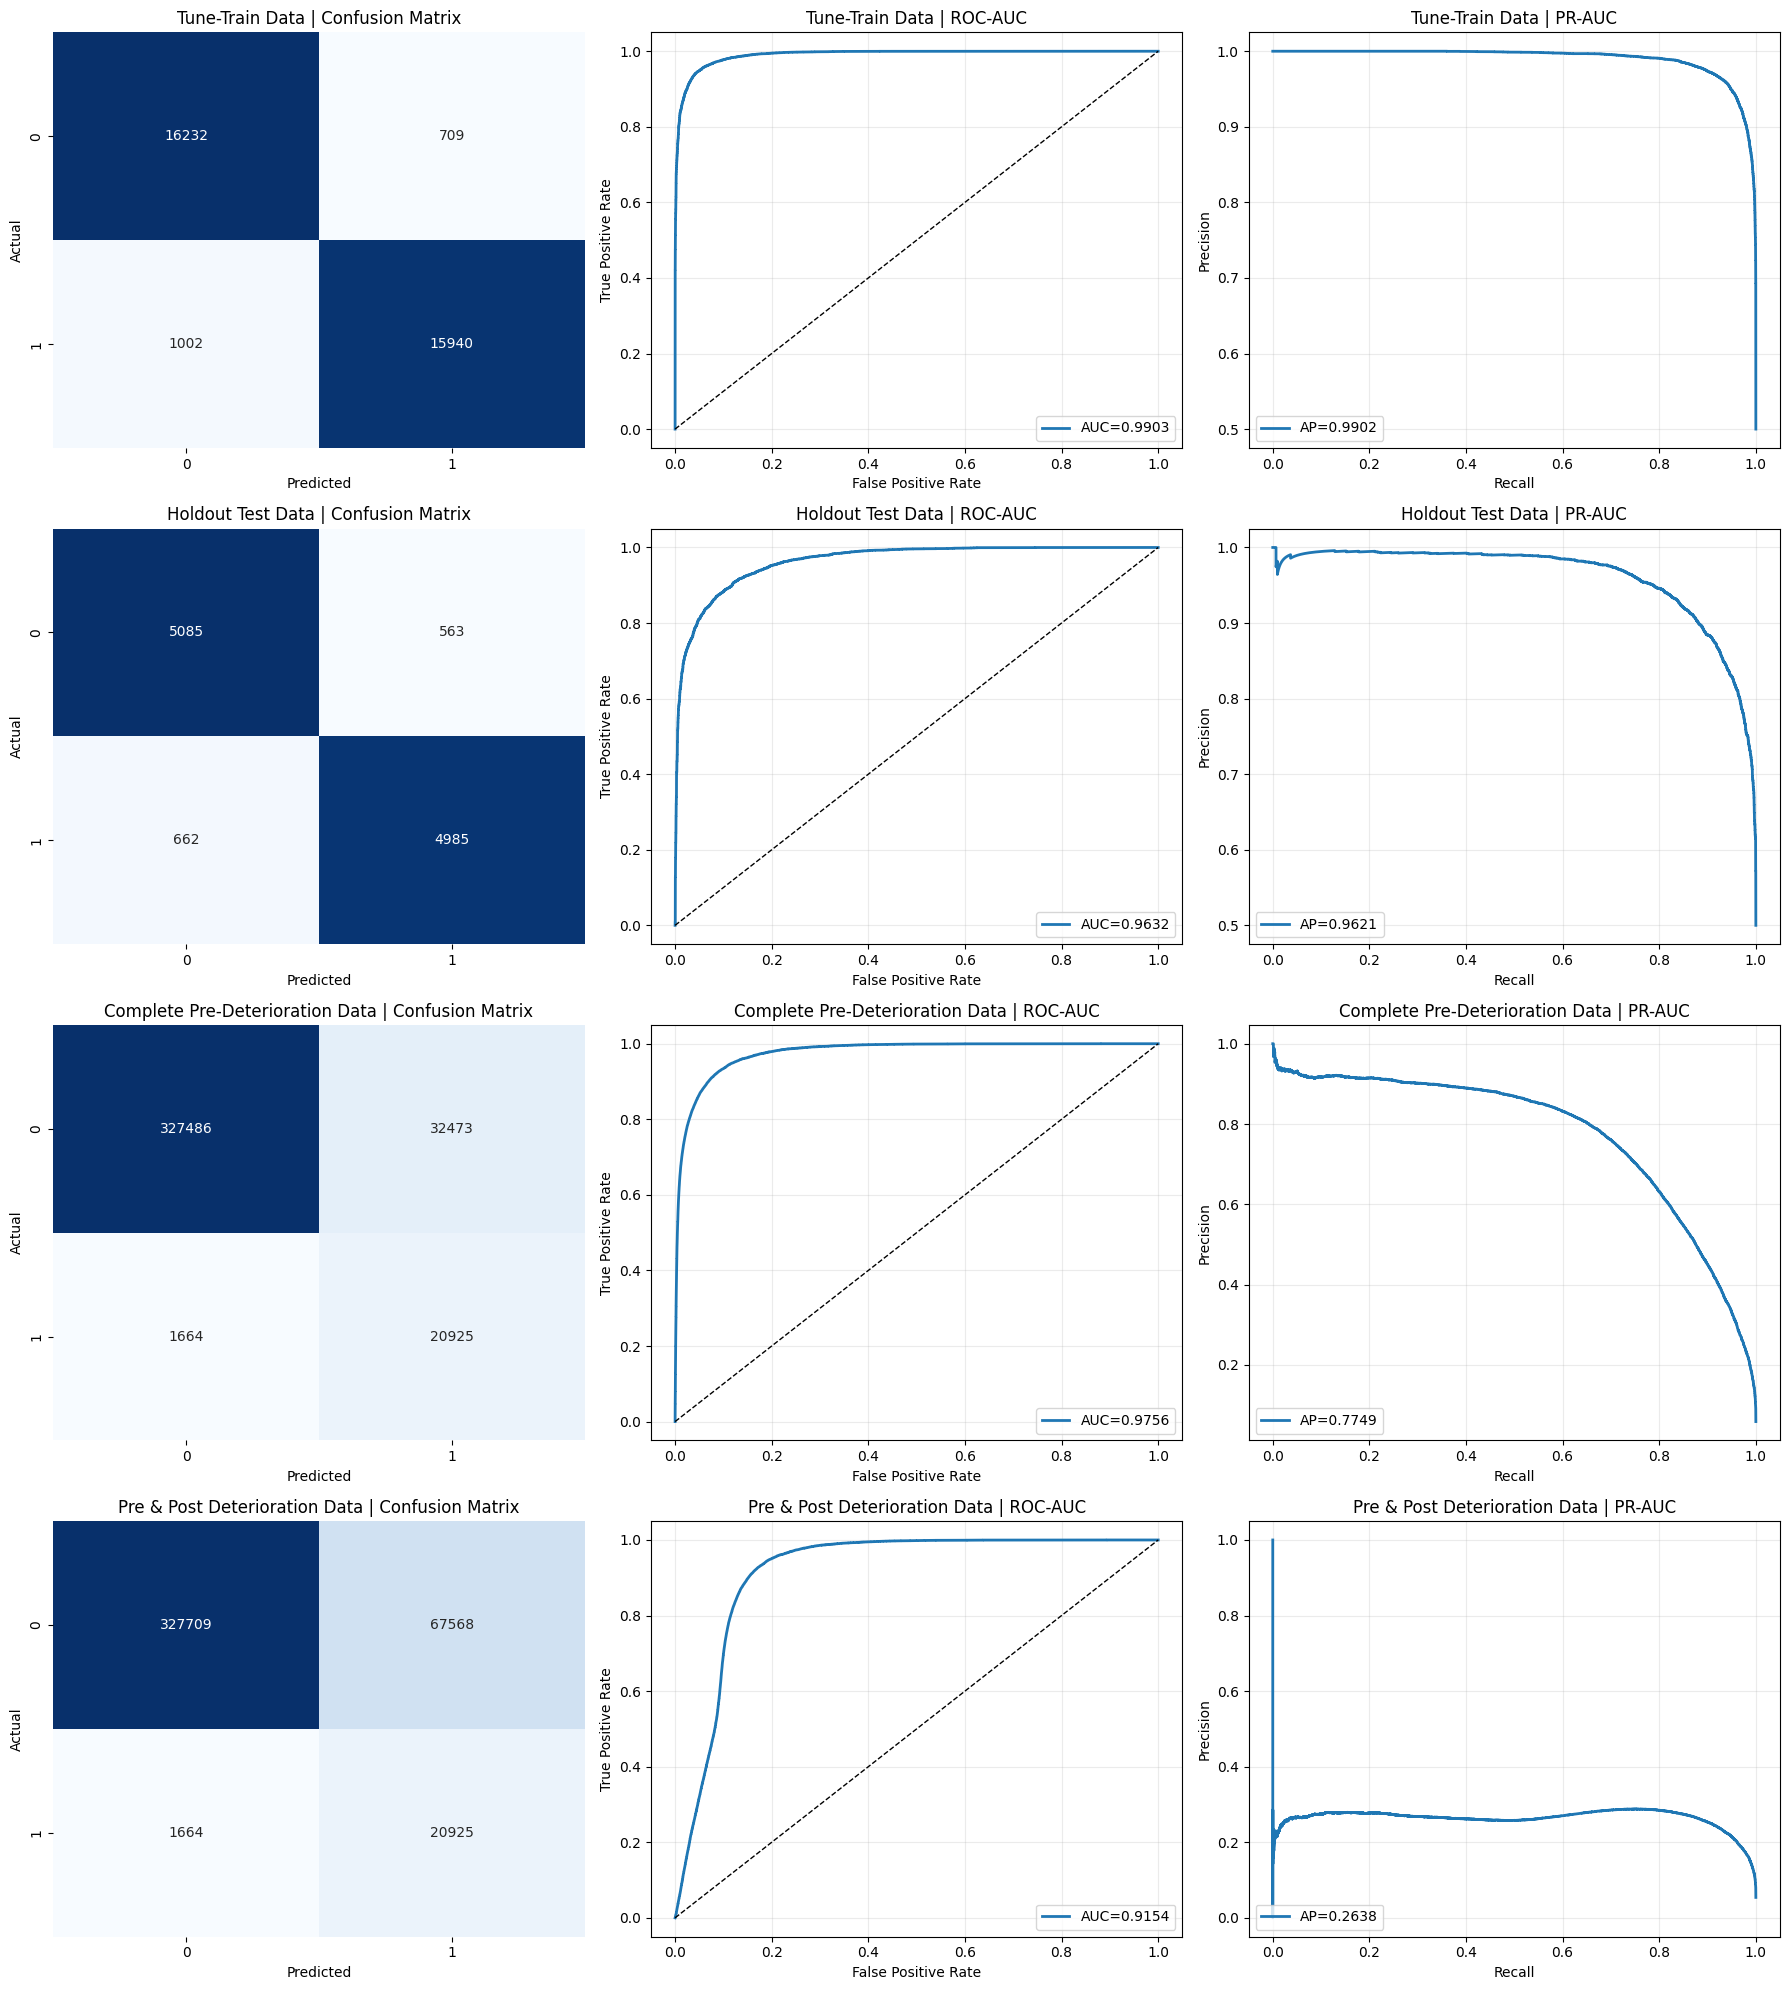

  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =  
 Randome Forest 
 = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 


,dataset_label,n_rows,recall,precision,f1,roc_auc
0,Tune-Train Data,33883,0.999941,0.998056,0.998998,0.999975
1,Holdout Test Data,11295,0.875155,0.905460,0.890050,0.960676
2,Complete Pre-Deterioration Data,382548,0.968746,0.411582,0.577716,0.986230
3,Pre & Post Deterioration Data,417866,0.968746,0.247705,0.394530,0.953771


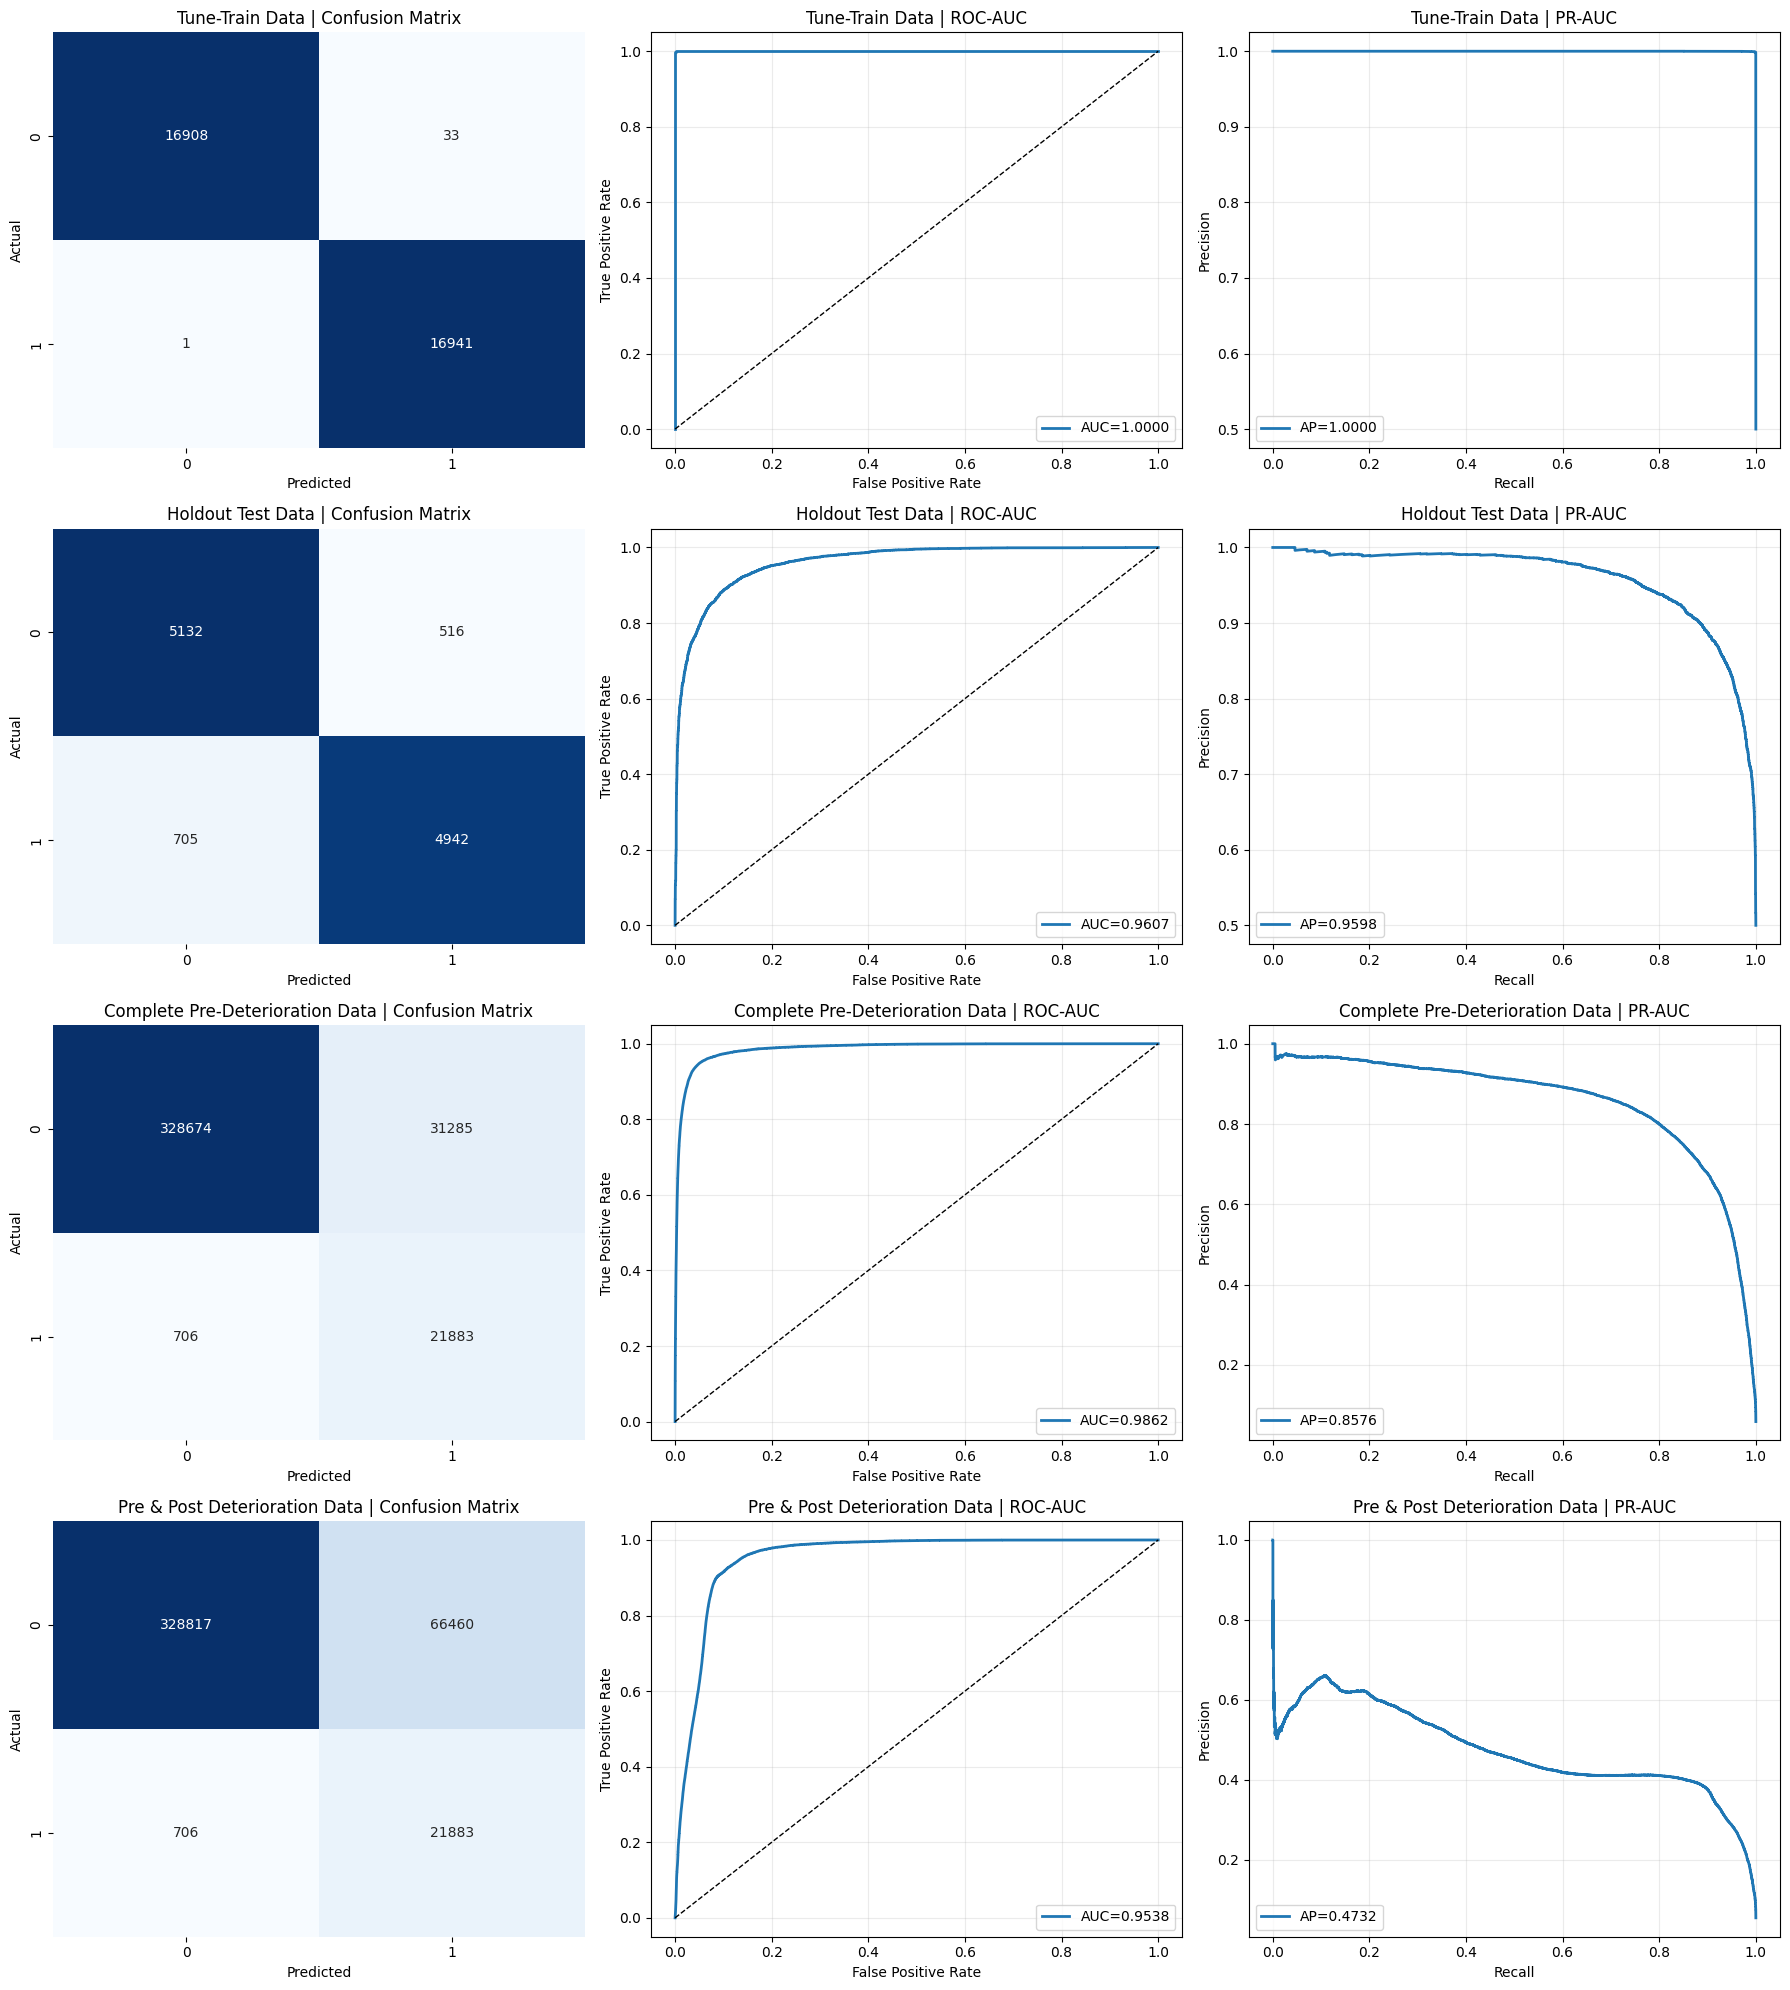

  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =  
 Boosted Logistic Regression 
 = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 


,dataset_label,n_rows,recall,precision,f1,roc_auc
0,Tune-Train Data,33883,0.823870,0.870254,0.846427,0.930757
1,Holdout Test Data,11295,0.821675,0.869239,0.844788,0.929172
2,Complete Pre-Deterioration Data,382548,0.823321,0.299755,0.439498,0.931367
3,Pre & Post Deterioration Data,417866,0.823321,0.191835,0.311167,0.853240


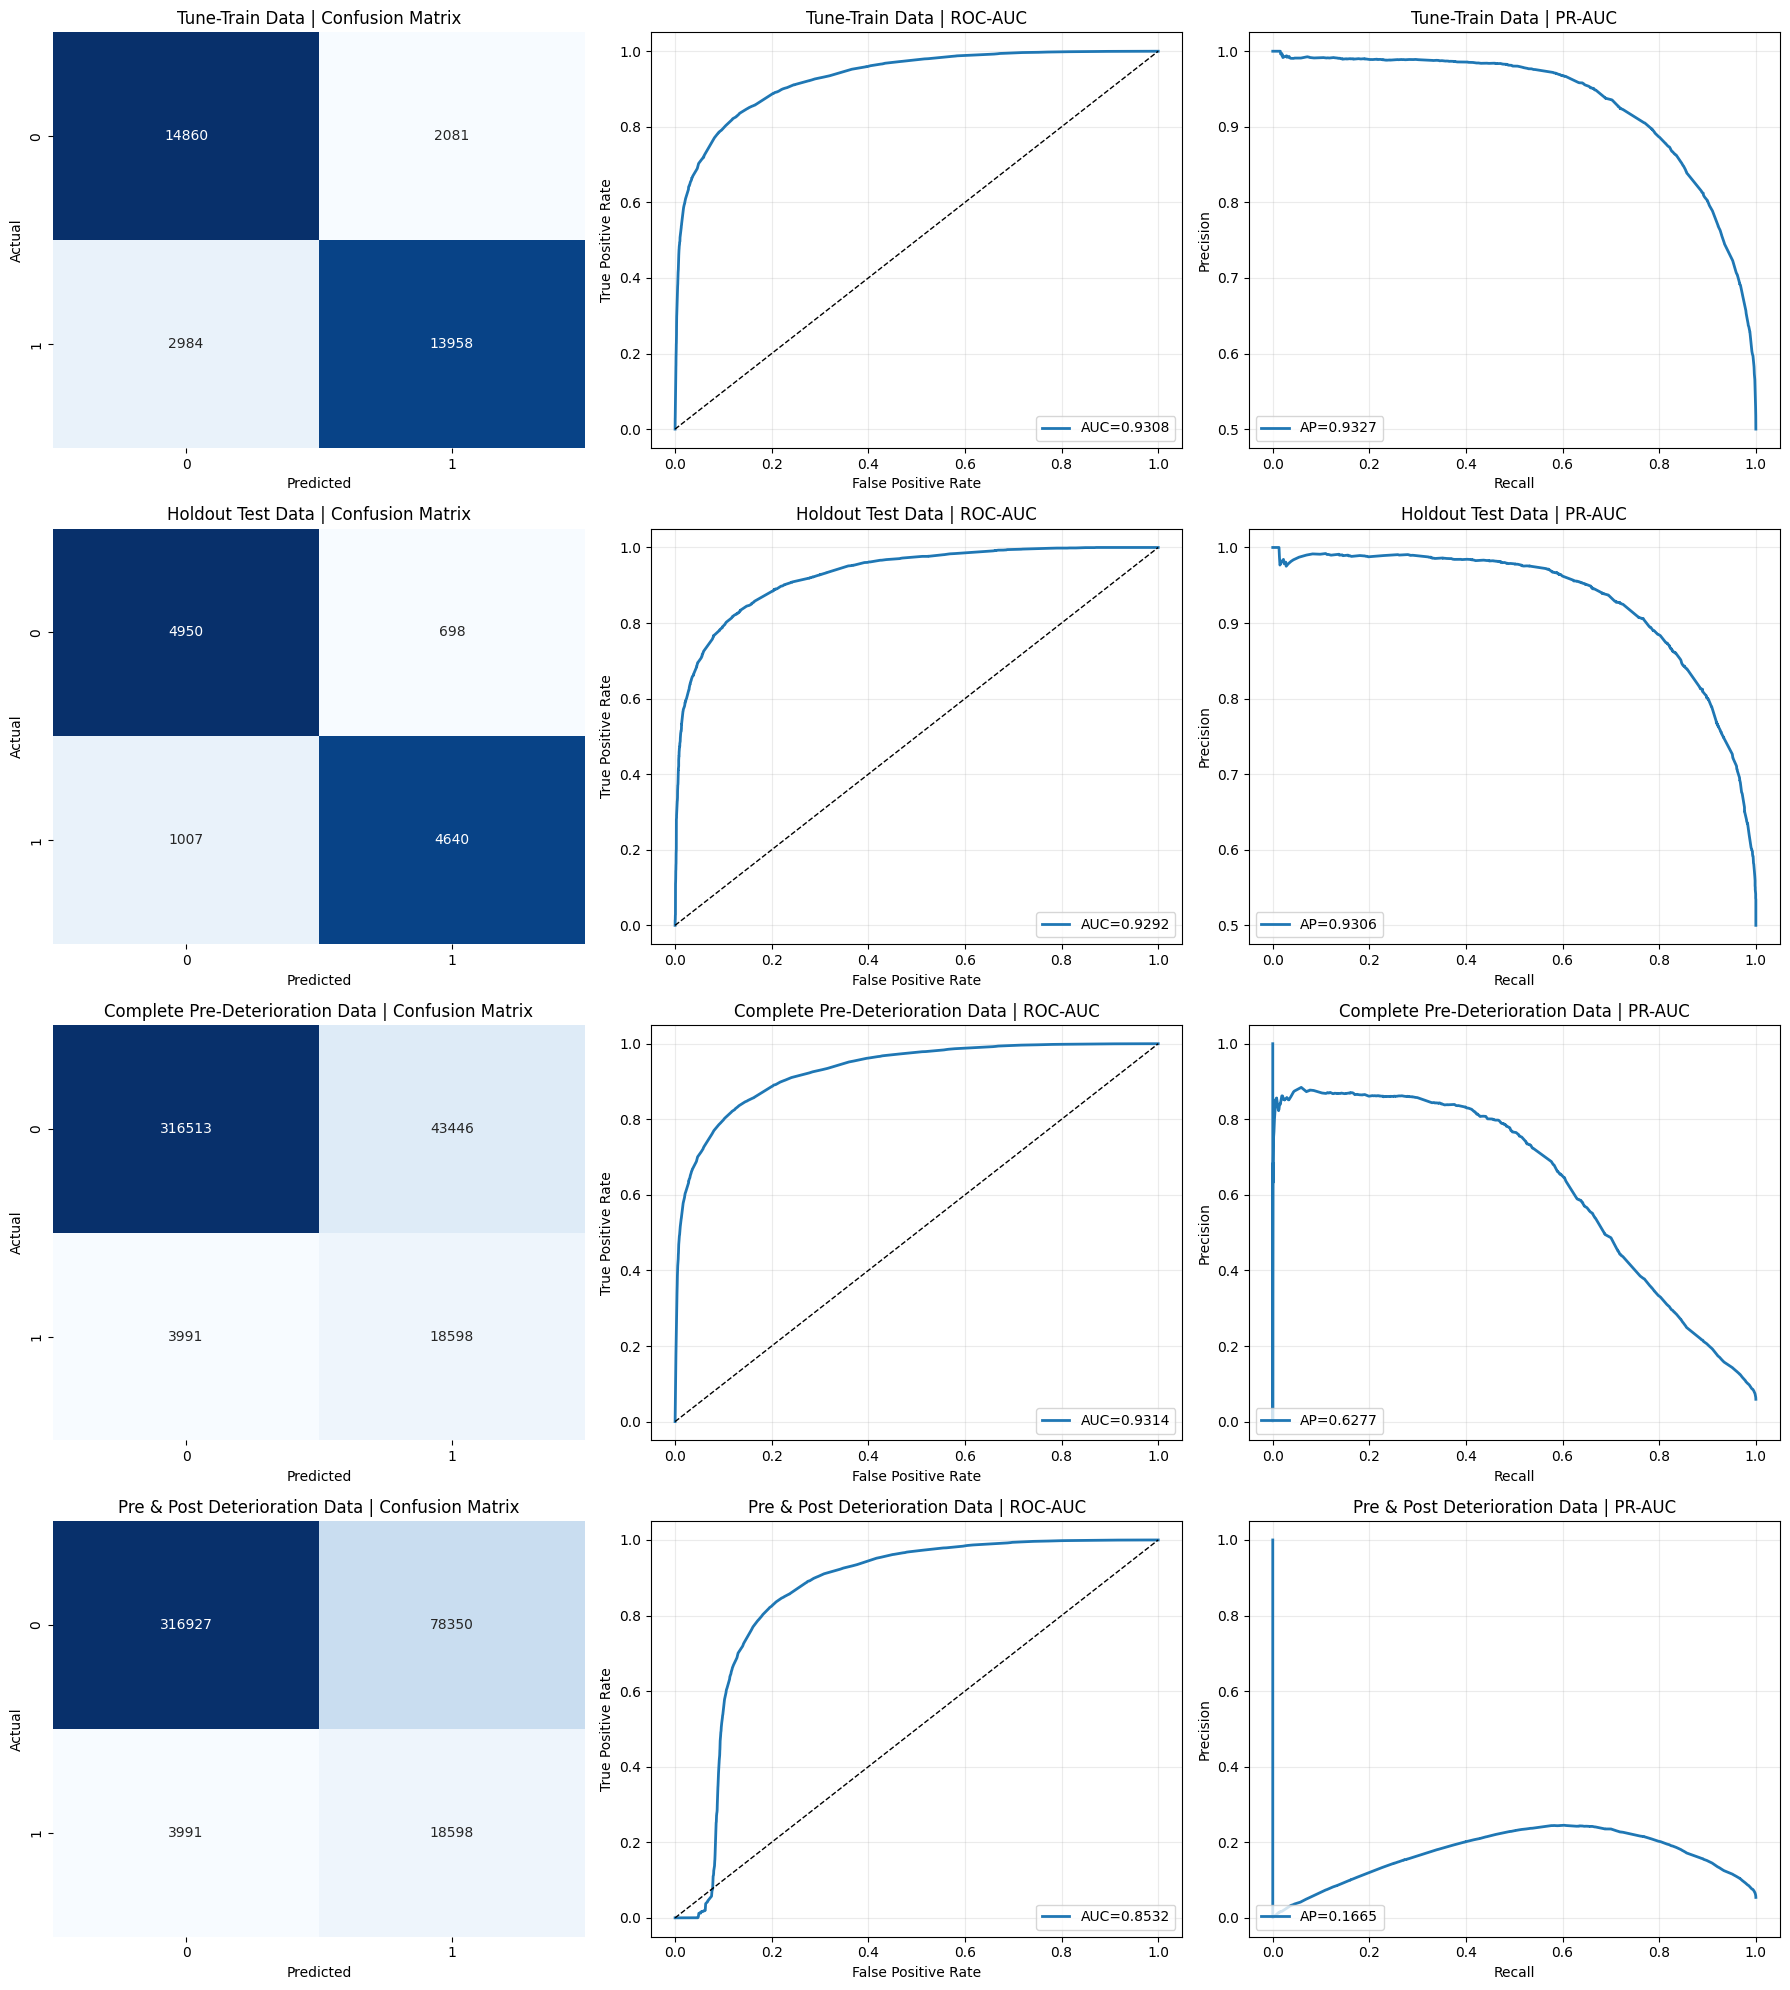

  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =  
 Boosted MLP 
 = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 


,dataset_label,n_rows,recall,precision,f1,roc_auc
0,Tune-Train Data,33883,0.839511,0.881118,0.859811,0.938464
1,Holdout Test Data,11295,0.835665,0.880410,0.857454,0.934813
2,Complete Pre-Deterioration Data,382548,0.838550,0.317451,0.460551,0.937433
3,Pre & Post Deterioration Data,417866,0.838550,0.199869,0.322799,0.878279


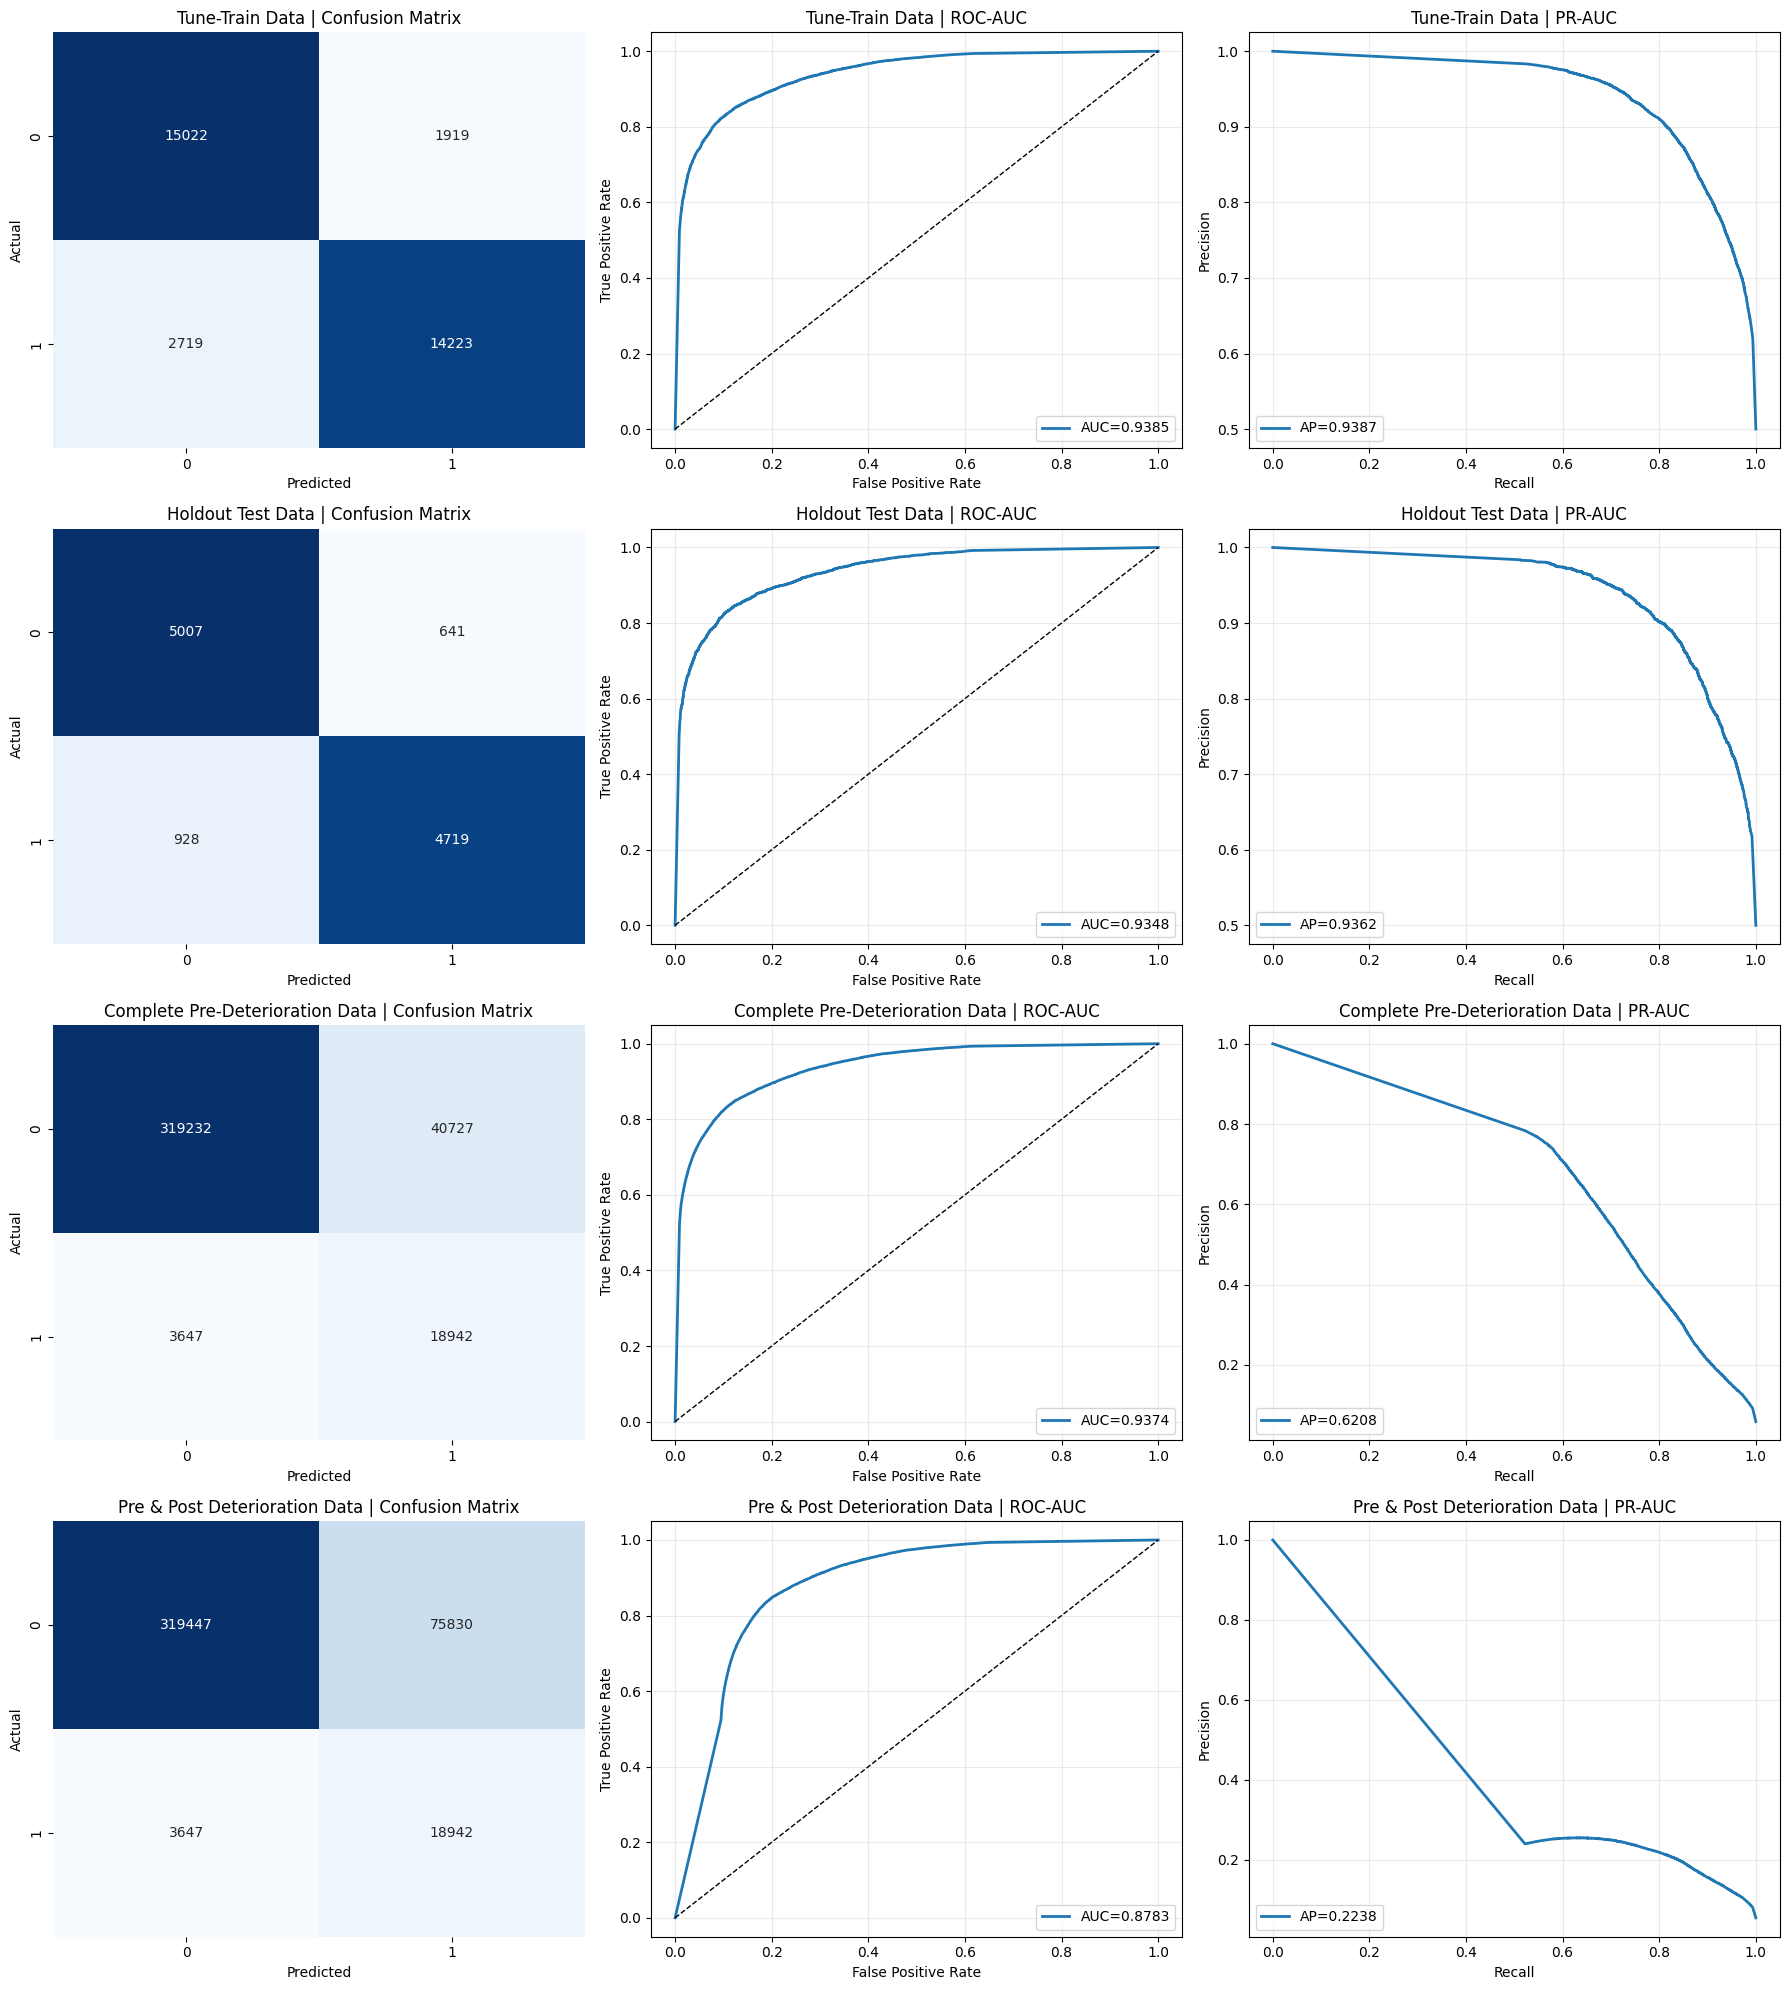

  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =  
 Boosted Perceptron 
 = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 


,dataset_label,n_rows,recall,precision,f1,roc_auc
0,Tune-Train Data,33883,0.847539,0.848490,0.848014,0.929577
1,Holdout Test Data,11295,0.847884,0.848034,0.847959,0.929471
2,Complete Pre-Deterioration Data,382548,0.847625,0.263236,0.401716,0.930611
3,Pre & Post Deterioration Data,417866,0.847625,0.177687,0.293787,0.856357


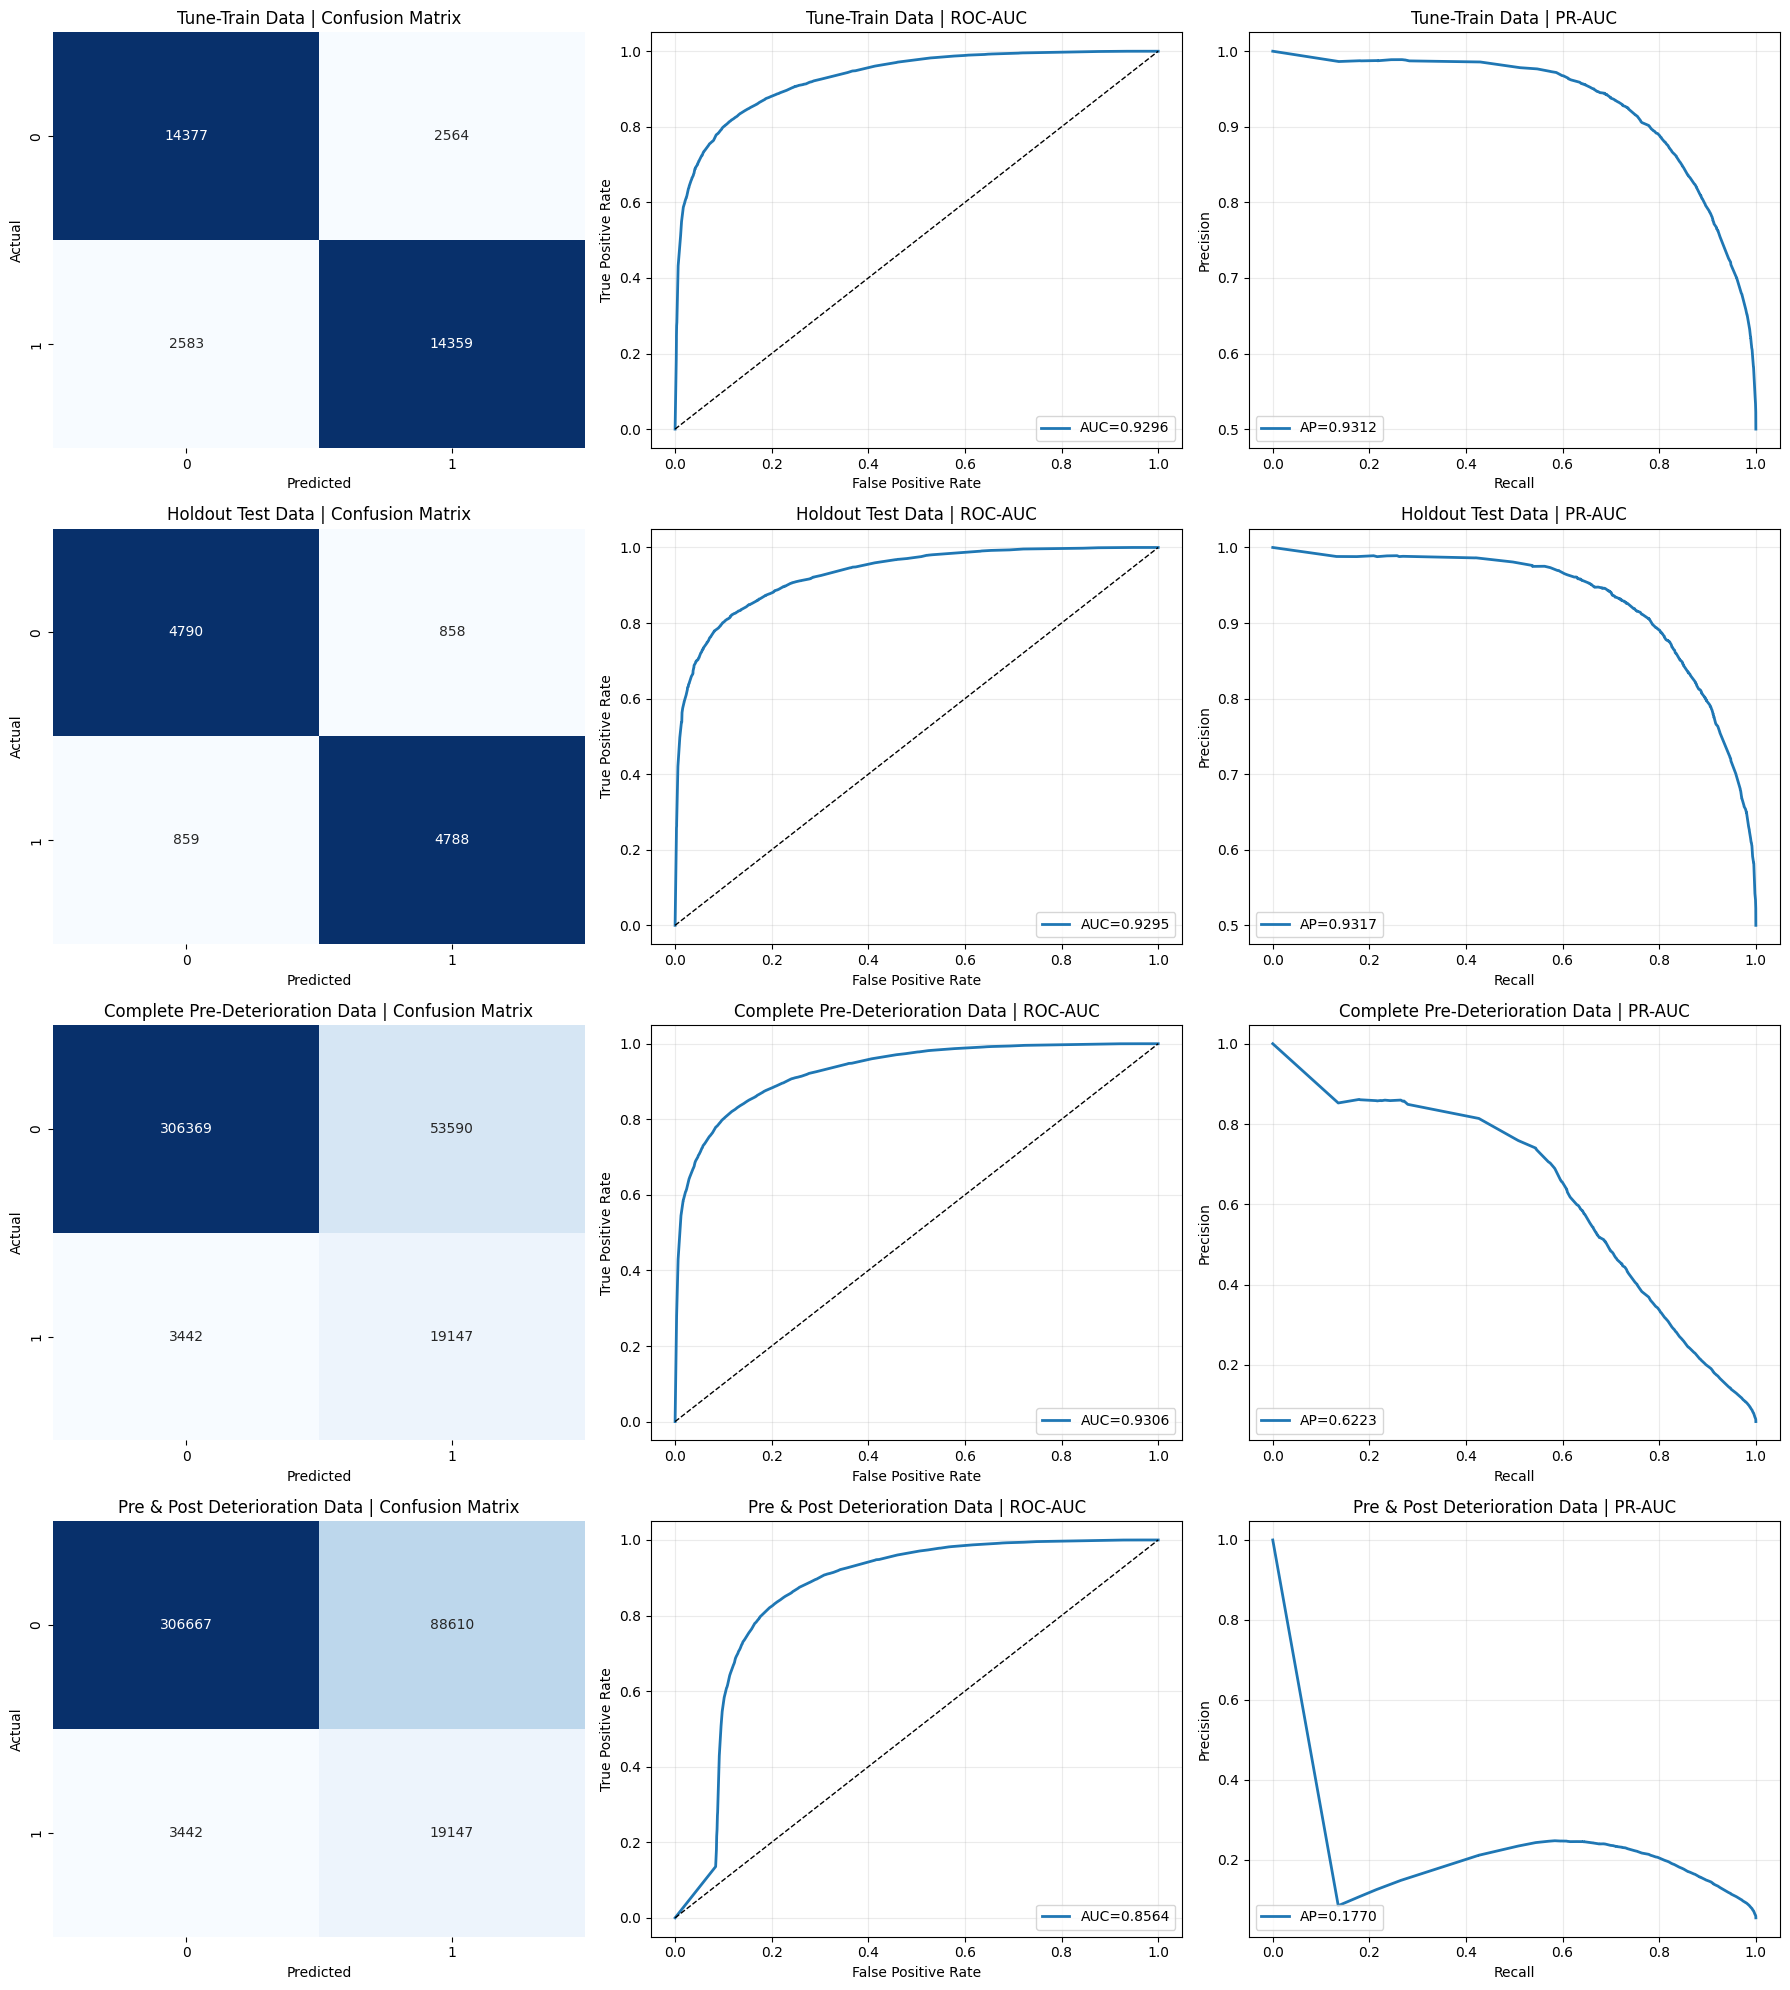

In [19]:
for mod, para in models.items():
    print(' ','= = '*25,'\n',mod,'\n','= = '*25)
    model,  fitted_transformer = analyze_one_model(**para,
                    pre_deterioration_data=new_data,
                    ml_ready_data=deterioration_ml_ready, 
                    )

In [21]:
import sklearn
print(sklearn.__version__)

1.7.2
